# Домашнее задание №3. Поиск аномалий в банковских транзакциях

**Цель:** построить и сравнить несколько unsupervised-алгоритмов поиска мошеннических
транзакций из разных семейств, используя известную долю `Class = 1` только как экспертную
оценку загрязнённости. Метки не используются при обучении моделей и выборе порогов; они
открываются только для итоговой оценки.

В работе используются:

1. **робастное диагональное расстояние Махаланобиса** — метод на расстояниях;
2. **HBOS (Histogram-Based Outlier Score)** — метод на плотностях;
3. **Isolation Forest** — модельный ансамблевый метод.

Качество оценивается на отложенной выборке с помощью `classification_report`, матриц
ошибок, precision, recall, F1, balanced accuracy, ROC-AUC и Average Precision (PR-AUC).
Для визуальной проверки строится t-SNE-представление.

## 1. Импорты и настройки

Все случайные операции фиксированы через `RANDOM_STATE`. Ноутбук ожидает файл
`creditcard.csv` в той же папке, что и сам ноутбук.

In [1]:
from pathlib import Path
from time import perf_counter
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from sklearn.ensemble import IsolationForest
from sklearn.manifold import TSNE
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

## 2. Загрузка и первичная проверка данных

In [2]:
data_path = Path("creditcard.csv")
if not data_path.exists():
    raise FileNotFoundError(
        "Поместите creditcard.csv из Kaggle рядом с ноутбуком: "
        "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
    )

df = pd.read_csv(data_path)
expected_columns = {"Time", "Amount", "Class", *[f"V{i}" for i in range(1, 29)]}
assert expected_columns == set(df.columns), "Набор столбцов отличается от ожидаемого"

print(f"Размер: {df.shape[0]:,} строк × {df.shape[1]} столбцов")
print(f"Пропусков: {df.isna().sum().sum():,}")
print(f"Полных дубликатов: {df.duplicated().sum():,}")
print("Типы данных:")
display(df.dtypes.value_counts().rename("число столбцов").to_frame())
display(df.head())

Размер: 284,807 строк × 31 столбцов
Пропусков: 0
Полных дубликатов: 1,081
Типы данных:


,число столбцов
float64,30
int64,1


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


Полные дубликаты далее не удаляются: сохраняется каноническая версия Kaggle-датасета и
его исходная доля мошенничества. Это следует учитывать при интерпретации метрик: повторные
наблюдения могут немного облегчать оценку. Целевая переменная не передаётся ни одному
алгоритму поиска аномалий.

## 3. EDA: описательные статистики

In [3]:
# Обязательные описательные статистики для всех числовых признаков и целевой переменной.
descriptive = df.describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]).T
display(descriptive)

,count,mean,std,min,1%,25%,50%,75%,99%,max
Time,"284,807.0000","94,813.8596","47,488.1460",0.0000,"2,422.0000","54,201.5000","84,692.0000","139,320.5000","170,560.9400","172,792.0000"
V1,"284,807.0000",0.0000,1.9587,-56.4075,-6.5632,-0.9204,0.0181,1.3156,2.2371,2.4549
V2,"284,807.0000",0.0000,1.6513,-72.7157,-4.9603,-0.5985,0.0655,0.8037,3.8018,22.0577
V3,"284,807.0000",-0.0000,1.5163,-48.3256,-3.9784,-0.8904,0.1798,1.0272,2.7284,9.3826
V4,"284,807.0000",0.0000,1.4159,-5.6832,-3.1230,-0.8486,-0.0198,0.7433,4.2480,16.8753
V5,"284,807.0000",0.0000,1.3802,-113.7433,-3.0604,-0.6916,-0.0543,0.6119,3.4249,34.8017
V6,"284,807.0000",0.0000,1.3323,-26.1605,-2.1240,-0.7683,-0.2742,0.3986,4.2001,73.3016
V7,"284,807.0000",-0.0000,1.2371,-43.5572,-3.0128,-0.5541,0.0401,0.5704,2.6962,120.5895
V8,"284,807.0000",0.0000,1.1944,-73.2167,-4.0339,-0.2086,0.0224,0.3273,2.0760,20.0072
V9,"284,807.0000",-0.0000,1.0986,-13.4341,-2.4553,-0.6431,-0.0514,0.5971,2.9868,15.5950


In [4]:
class_summary = (
    df["Class"]
    .value_counts()
    .sort_index()
    .rename_axis("Class")
    .to_frame("count")
)
class_summary["share"] = class_summary["count"] / len(df)
display(class_summary)

contamination = float(df["Class"].mean())
print(f"Экспертная оценка contamination = {contamination:.8f} "
      f"({contamination:.4%}, или примерно 1 случай на {1 / contamination:.0f} транзакций)")

,count,share
Class,,
0,284315,0.9983
1,492,0.0017


Экспертная оценка contamination = 0.00172749 (0.1727%, или примерно 1 случай на 579 транзакций)


Класс крайне несбалансирован: обычная accuracy здесь почти бесполезна — классификатор,
всегда отвечающий «норма», получил бы accuracy около 99.8%. Поэтому основной акцент ниже
сделан на precision/recall/F1 класса `1` и PR-AUC.

## 4. EDA: гистограммы и распределения

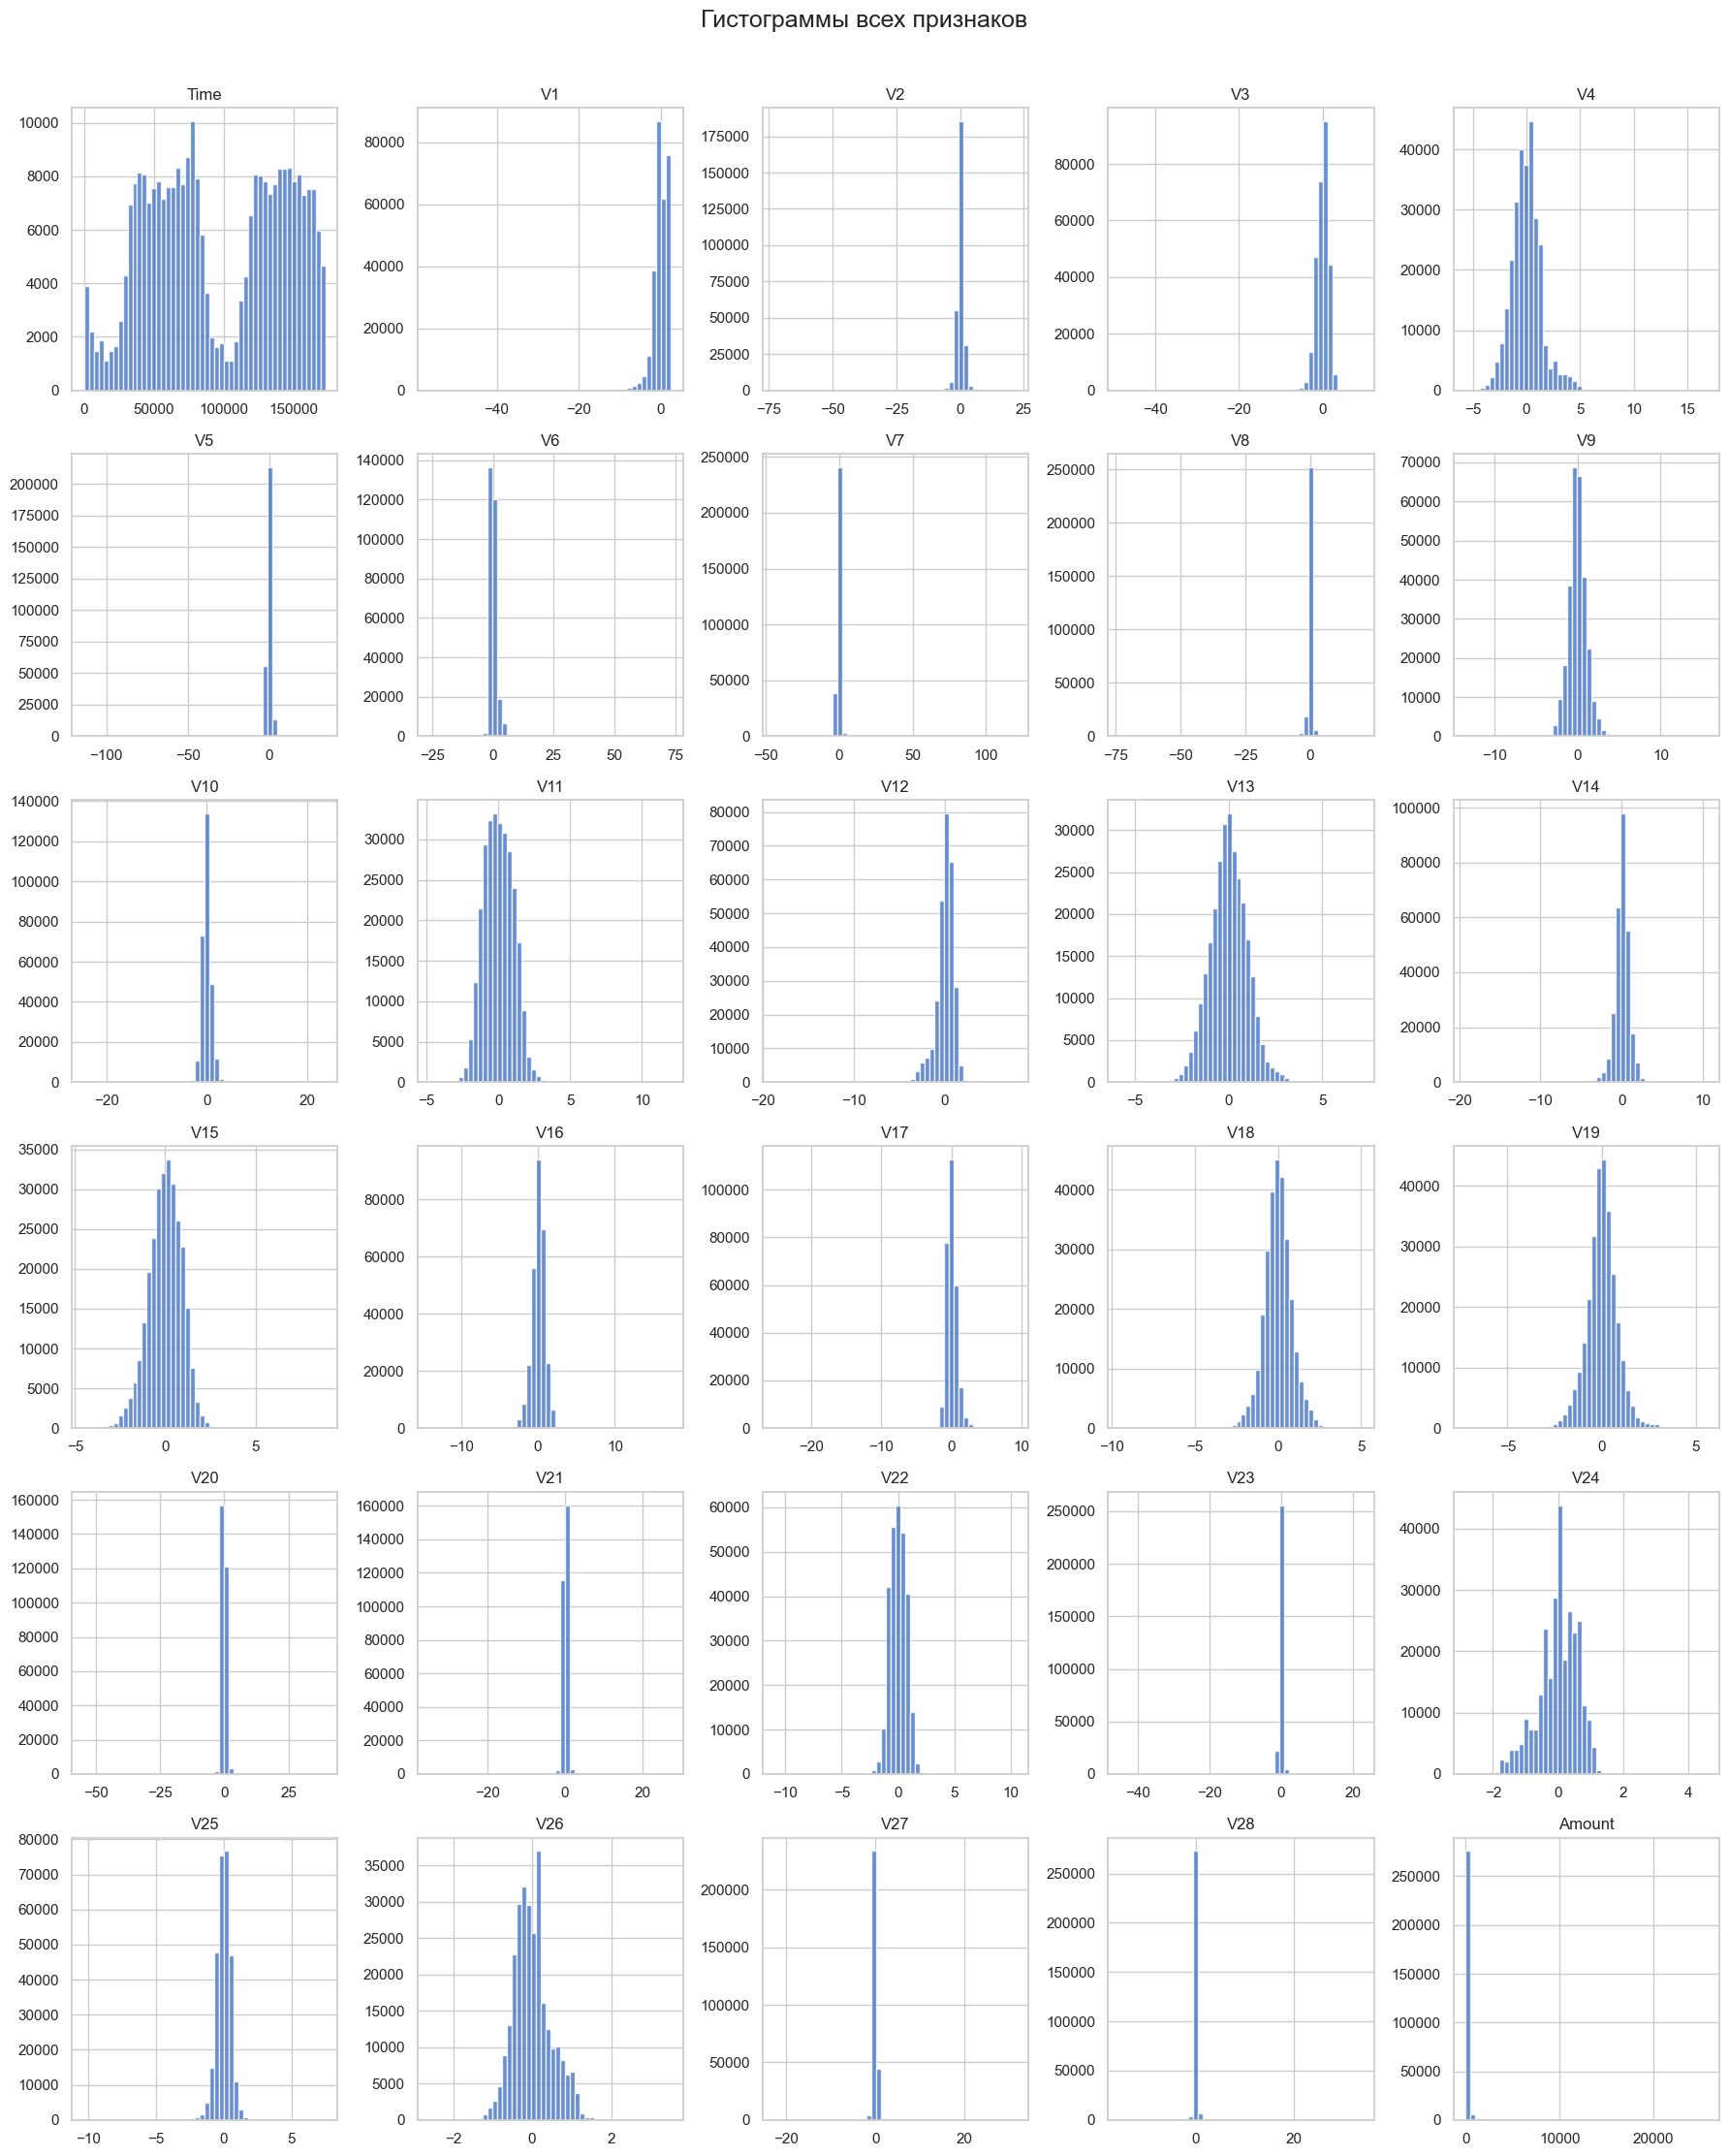

In [5]:
feature_columns = [c for c in df.columns if c != "Class"]
axes = df[feature_columns].hist(
    bins=50, figsize=(18, 22), layout=(6, 5), color="#4472C4", alpha=0.8
)
plt.suptitle("Гистограммы всех признаков", fontsize=18, y=1.01)
plt.tight_layout()
plt.show()

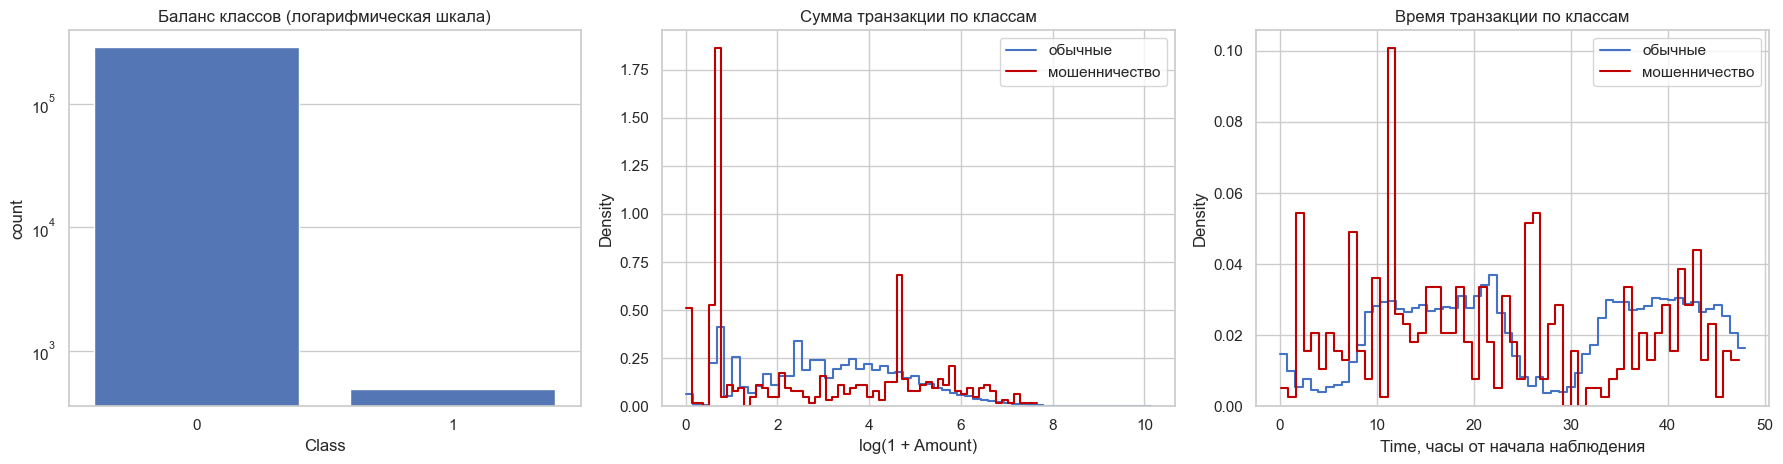

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

sns.countplot(data=df, x="Class", ax=axes[0], color="#4472C4")
axes[0].set_yscale("log")
axes[0].set_title("Баланс классов (логарифмическая шкала)")

for cls, color, label in [(0, "#4472C4", "обычные"), (1, "#C00000", "мошенничество")]:
    sns.histplot(
        np.log1p(df.loc[df["Class"] == cls, "Amount"]),
        bins=60, stat="density", element="step", fill=False,
        color=color, label=label, ax=axes[1]
    )
axes[1].set_xlabel("log(1 + Amount)")
axes[1].set_title("Сумма транзакции по классам")
axes[1].legend()

for cls, color, label in [(0, "#4472C4", "обычные"), (1, "#C00000", "мошенничество")]:
    sns.histplot(
        df.loc[df["Class"] == cls, "Time"] / 3600,
        bins=60, stat="density", element="step", fill=False,
        color=color, label=label, ax=axes[2]
    )
axes[2].set_xlabel("Time, часы от начала наблюдения")
axes[2].set_title("Время транзакции по классам")
axes[2].legend()

plt.tight_layout()
plt.show()

,corr(Class)
V17,-0.3265
V14,-0.3025
V12,-0.2606
V10,-0.2169
V16,-0.1965
V3,-0.1930
V7,-0.1873
V11,0.1549
V4,0.1334
V18,-0.1115


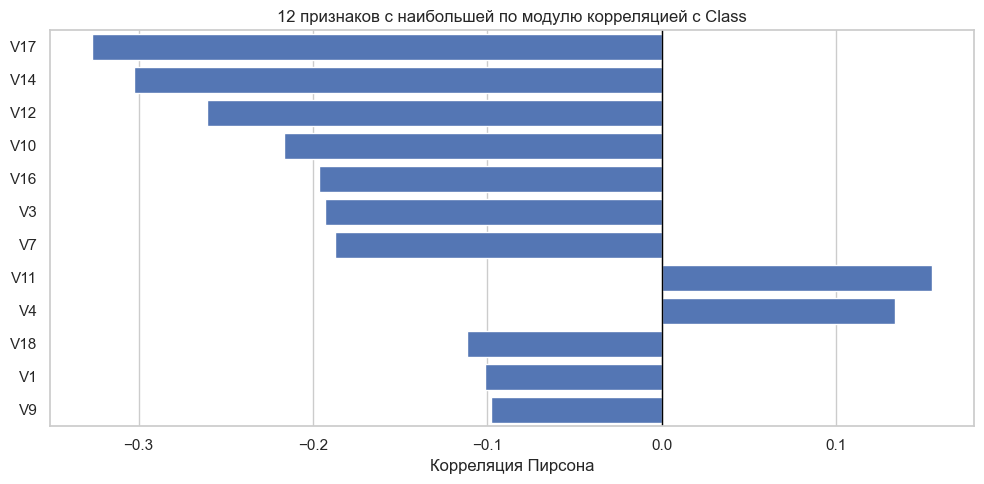

In [7]:
correlations = (
    df.corr(numeric_only=True)["Class"]
    .drop("Class")
    .sort_values(key=np.abs, ascending=False)
)
display(correlations.head(12).rename("corr(Class)").to_frame())

plt.figure(figsize=(10, 5))
sns.barplot(x=correlations.head(12).values, y=correlations.head(12).index, color="#4472C4")
plt.axvline(0, color="black", linewidth=1)
plt.title("12 признаков с наибольшей по модулю корреляцией с Class")
plt.xlabel("Корреляция Пирсона")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Выводы EDA.** Пропусков нет; все признаки числовые. `V1`–`V28` уже являются
анонимизированными PCA-компонентами, а `Time` и `Amount` имеют иной масштаб, поэтому перед
геометрическими и плотностными методами нужна стандартизация. Распределения многих
компонент имеют тяжёлые хвосты. Корреляции с `Class` показаны только для анализа — они не
используются для отбора признаков, чтобы сохранить unsupervised-постановку.

## 5. Контрольное разбиение без обучения по меткам

In [8]:
X = df.drop(columns="Class")
y = df["Class"].astype(int)

# Stratify нужен только для устойчивой итоговой оценки редкого класса.
# После split метки y_train/y_test не передаются fit/threshold ни одного детектора.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

print(f"Train: {len(X_train):,}; test: {len(X_test):,}")
print(f"Доля Class=1 в train: {y_train.mean():.4%}; в test: {y_test.mean():.4%}")
print("Важно: contamination зафиксирован по исходному датасету до оценки моделей:", contamination)

Train: 227,845; test: 56,962
Доля Class=1 в train: 0.1729%; в test: 0.1720%
Важно: contamination зафиксирован по исходному датасету до оценки моделей: 0.001727485630620034


## 6. Детекторы аномалий

Для всех методов действует одно правило: чем выше score, тем объект аномальнее. Порог
определяется **только по train-score** как квантиль `1 - contamination`. Это заставляет
каждый метод считать аномальными примерно экспертно заданные 0.17% обучающих объектов и
исключает подгонку порога по тестовым меткам.

### 6.1. Метод на расстояниях: робастное диагональное расстояние Махаланобиса

Для каждого признака оцениваются медиана и MAD. Score — евклидова длина в координатах,
центрированных медианой и масштабированных робастной оценкой разброса. В отличие от полного
Mahalanobis, диагональный вариант устойчив и вычислительно линеен по числу строк.

In [9]:
class RobustDiagonalDistance:
    def fit(self, X):
        X = np.asarray(X, dtype=np.float64)
        self.center_ = np.median(X, axis=0)
        mad = np.median(np.abs(X - self.center_), axis=0)
        robust_scale = 1.4826 * mad
        fallback = np.std(X, axis=0)
        self.scale_ = np.where(robust_scale > 1e-12, robust_scale, fallback)
        self.scale_ = np.where(self.scale_ > 1e-12, self.scale_, 1.0)
        return self

    def score_samples(self, X):
        z = (np.asarray(X, dtype=np.float64) - self.center_) / self.scale_
        return np.sqrt(np.sum(z ** 2, axis=1))

### 6.2. Метод на плотностях: HBOS

Для каждого признака строится одномерная гистограмма плотности. Независимость признаков —
приближение, но после PCA оно выглядит разумнее, чем для исходных коррелированных полей.
Итоговый score равен сумме отрицательных логарифмов сглаженных вероятностей по признакам.

In [10]:
class HBOS:
    def __init__(self, n_bins=30, alpha=1.0):
        self.n_bins = n_bins
        self.alpha = alpha

    def fit(self, X):
        X = np.asarray(X, dtype=np.float64)
        self.edges_, self.probs_ = [], []
        for j in range(X.shape[1]):
            col = X[:, j]
            lo, hi = np.quantile(col, [0.001, 0.999])
            if not np.isfinite(lo) or not np.isfinite(hi) or lo >= hi:
                lo, hi = np.min(col), np.max(col) + 1e-9
            edges = np.linspace(lo, hi, self.n_bins + 1)
            clipped = np.clip(col, lo, hi)
            idx = np.clip(np.searchsorted(edges, clipped, side="right") - 1, 0, self.n_bins - 1)
            counts = np.bincount(idx, minlength=self.n_bins)
            probs = (counts + self.alpha) / (len(col) + self.alpha * self.n_bins)
            self.edges_.append(edges)
            self.probs_.append(probs)
        return self

    def score_samples(self, X):
        X = np.asarray(X, dtype=np.float64)
        scores = np.zeros(len(X), dtype=np.float64)
        for j, (edges, probs) in enumerate(zip(self.edges_, self.probs_)):
            col = X[:, j]
            clipped = np.clip(col, edges[0], edges[-1])
            idx = np.clip(np.searchsorted(edges, clipped, side="right") - 1, 0, len(probs) - 1)
            point_probs = probs[idx].copy()
            outside = (col < edges[0]) | (col > edges[-1])
            point_probs[outside] = np.minimum(point_probs[outside], probs.min() * 0.1)
            scores -= np.log(np.maximum(point_probs, 1e-300))
        return scores

### 6.3. Модельный метод: Isolation Forest

Случайные деревья рекурсивно изолируют объекты. Аномалии обычно требуют меньше разбиений,
поскольку расположены в редких областях пространства. Параметр `contamination` установлен
равным экспертной оценке из `Class`.

In [11]:
detectors = {
    "Robust distance": RobustDiagonalDistance(),
    "HBOS": HBOS(n_bins=30, alpha=1.0),
    "Isolation Forest": IsolationForest(
        n_estimators=250,
        contamination=contamination,
        max_samples="auto",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

train_scores, test_scores, thresholds, predictions, timings = {}, {}, {}, {}, {}

for name, detector in detectors.items():
    started = perf_counter()
    detector.fit(X_train_scaled)

    if name == "Isolation Forest":
        # sklearn: большие score_samples означают норму, поэтому меняем знак.
        score_train = -detector.score_samples(X_train_scaled)
        score_test = -detector.score_samples(X_test_scaled)
    else:
        score_train = detector.score_samples(X_train_scaled)
        score_test = detector.score_samples(X_test_scaled)

    threshold = np.quantile(score_train, 1 - contamination)
    pred = (score_test >= threshold).astype(int)

    train_scores[name] = score_train
    test_scores[name] = score_test
    thresholds[name] = threshold
    predictions[name] = pred
    timings[name] = perf_counter() - started

    print(
        f"{name:18s}: threshold={threshold:.5f}, "
        f"аномалий в test={pred.mean():.4%}, время={timings[name]:.2f} с"
    )

Robust distance   : threshold=96.76402, аномалий в test=0.1861%, время=0.79 с
HBOS              : threshold=168.50677, аномалий в test=0.1791%, время=1.36 с
Isolation Forest  : threshold=0.65295, аномалий в test=0.1843%, время=14.34 с


HBOS              : threshold=168.50677, аномалий в test=0.1791%, время=0.56 с


Isolation Forest  : threshold=0.65295, аномалий в test=0.1843%, время=5.44 с


## 7. Оценка качества на отложенной выборке

In [12]:
metric_rows = []
reports = {}

for name in detectors:
    pred = predictions[name]
    score = test_scores[name]
    reports[name] = classification_report(
        y_test, pred, target_names=["normal (0)", "fraud (1)"],
        digits=4, zero_division=0
    )
    metric_rows.append({
        "model": name,
        "precision_fraud": precision_score(y_test, pred, zero_division=0),
        "recall_fraud": recall_score(y_test, pred, zero_division=0),
        "f1_fraud": f1_score(y_test, pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "ROC_AUC(score)": roc_auc_score(y_test, score),
        "PR_AUC(score)": average_precision_score(y_test, score),
        "predicted_anomaly_share": pred.mean(),
        "seconds": timings[name],
    })

comparison = (
    pd.DataFrame(metric_rows)
    .set_index("model")
    .sort_values("PR_AUC(score)", ascending=False)
)
display(comparison.style.format({
    "precision_fraud": "{:.4f}", "recall_fraud": "{:.4f}",
    "f1_fraud": "{:.4f}", "balanced_accuracy": "{:.4f}",
    "ROC_AUC(score)": "{:.4f}", "PR_AUC(score)": "{:.4f}",
    "predicted_anomaly_share": "{:.4%}", "seconds": "{:.2f}",
}))

,precision_fraud,recall_fraud,f1_fraud,balanced_accuracy,ROC_AUC(score),PR_AUC(score),predicted_anomaly_share,seconds
model,,,,,,,,
HBOS,0.3235,0.3367,0.3300,0.6678,0.9535,0.2471,0.1791%,1.36
Isolation Forest,0.2857,0.3061,0.2956,0.6524,0.9540,0.1732,0.1843%,14.34
Robust distance,0.0283,0.0306,0.0294,0.5144,0.9324,0.0302,0.1861%,0.79


In [13]:
for name in detectors:
    print("=" * 78)
    print(name)
    print(reports[name])

Robust distance
              precision    recall  f1-score   support

  normal (0)     0.9983    0.9982    0.9983     56864
   fraud (1)     0.0283    0.0306    0.0294        98

    accuracy                         0.9965     56962
   macro avg     0.5133    0.5144    0.5138     56962
weighted avg     0.9967    0.9965    0.9966     56962

HBOS
              precision    recall  f1-score   support

  normal (0)     0.9989    0.9988    0.9988     56864
   fraud (1)     0.3235    0.3367    0.3300        98

    accuracy                         0.9976     56962
   macro avg     0.6612    0.6678    0.6644     56962
weighted avg     0.9977    0.9976    0.9977     56962

Isolation Forest
              precision    recall  f1-score   support

  normal (0)     0.9988    0.9987    0.9987     56864
   fraud (1)     0.2857    0.3061    0.2956        98

    accuracy                         0.9975     56962
   macro avg     0.6423    0.6524    0.6472     56962
weighted avg     0.9976    0.9975   

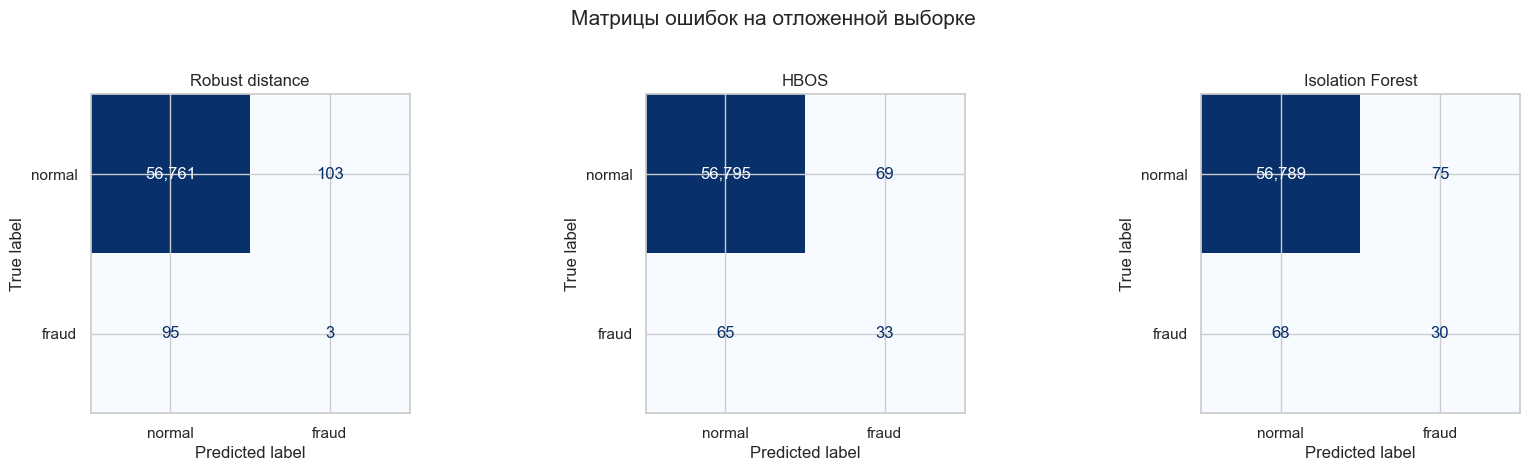

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
for ax, name in zip(axes, detectors):
    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_test, predictions[name]),
        display_labels=["normal", "fraud"]
    ).plot(ax=ax, cmap="Blues", colorbar=False, values_format=",d")
    ax.set_title(name)
plt.suptitle("Матрицы ошибок на отложенной выборке", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

**Как читать результаты.** ROC-AUC полезен как ранговая метрика, но при доле положительного
класса около 0.17% может выглядеть оптимистично. PR-AUC, precision, recall и F1 класса fraud
лучше отражают практический компромисс. Заданный contamination фиксирует бюджет тревог, но
не гарантирует, что найденные редкие точки действительно являются мошенничеством.

## 8. t-SNE: лежат ли аномалии далеко от основной массы?

In [15]:
# Все мошеннические операции из test + случайная выборка обычных операций.
# Это делает редкий класс видимым, поэтому доля цветов на графике не равна исходной доле.
fraud_idx = np.flatnonzero(y_test.to_numpy() == 1)
normal_idx = np.flatnonzero(y_test.to_numpy() == 0)
n_normal_vis = min(4000 - len(fraud_idx), len(normal_idx))
vis_idx = np.concatenate([fraud_idx, rng.choice(normal_idx, n_normal_vis, replace=False)])
rng.shuffle(vis_idx)

X_vis = X_test_scaled[vis_idx]
y_vis = y_test.to_numpy()[vis_idx]

tsne = TSNE(
    n_components=2,
    perplexity=35,
    init="pca",
    learning_rate="auto",
    max_iter=1000,
    random_state=RANDOM_STATE,
)
embedding = tsne.fit_transform(X_vis)
print(f"Визуализируется {len(vis_idx):,} точек, включая все fraud из test: {y_vis.sum()}")

Визуализируется 4,000 точек, включая все fraud из test: 98


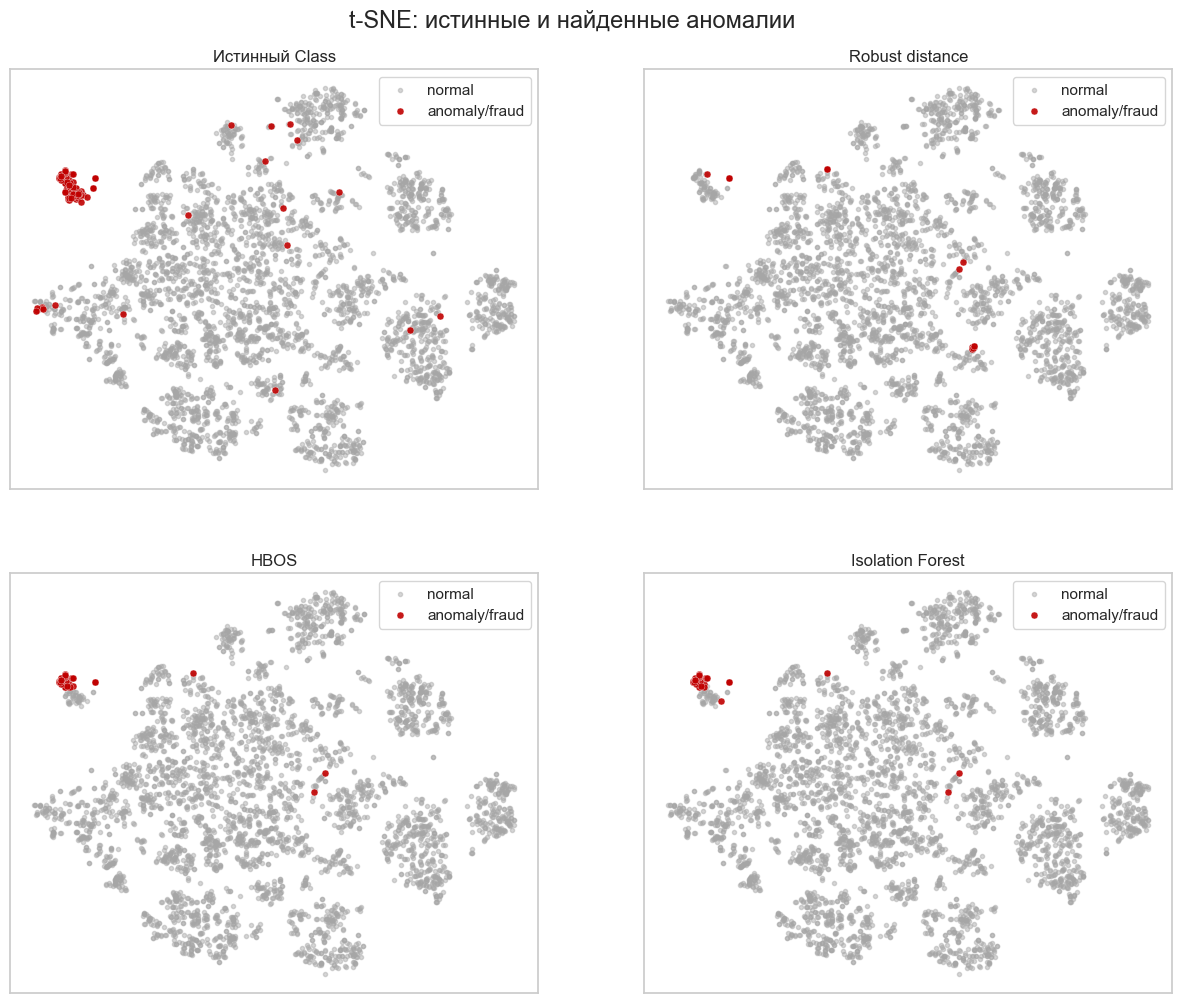

In [16]:
panels = [("Истинный Class", y_vis)] + [
    (name, predictions[name][vis_idx]) for name in detectors
]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
for ax, (title, labels) in zip(axes.flat, panels):
    normal = labels == 0
    anomaly = labels == 1
    ax.scatter(
        embedding[normal, 0], embedding[normal, 1],
        s=9, c="#A6A6A6", alpha=0.45, label="normal"
    )
    ax.scatter(
        embedding[anomaly, 0], embedding[anomaly, 1],
        s=25, c="#C00000", alpha=0.9, label="anomaly/fraud",
        edgecolors="white", linewidths=0.25
    )
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(loc="best")
plt.suptitle("t-SNE: истинные и найденные аномалии", fontsize=17, y=0.93)
plt.show()

In [17]:
# Простая количественная проверка в 2D: расстояние fraud до ближайшей normal-точки
# против расстояния normal до её ближайшего другого normal-соседа.
emb_normal = embedding[y_vis == 0]
emb_fraud = embedding[y_vis == 1]
nn = NearestNeighbors(n_neighbors=2).fit(emb_normal)
normal_neighbor_distance = nn.kneighbors(emb_normal)[0][:, 1]
fraud_to_normal_distance = nn.kneighbors(emb_fraud, n_neighbors=1)[0][:, 0]
separation_ratio = np.median(fraud_to_normal_distance) / np.median(normal_neighbor_distance)

print(f"Медиана normal → ближайшая другая normal: {np.median(normal_neighbor_distance):.3f}")
print(f"Медиана fraud → ближайшая normal:        {np.median(fraud_to_normal_distance):.3f}")
print(f"Отношение медиан: {separation_ratio:.2f}")

Медиана normal → ближайшая другая normal: 0.330
Медиана fraud → ближайшая normal:        3.629
Отношение медиан: 11.00


t-SNE сохраняет главным образом локальные соседства, но искажает глобальные расстояния и
зависит от выборки и параметров. Поэтому «острова» на таком графике — иллюстрация, а не
доказательство separability. Здесь намеренно показаны все fraud из test и подвыборка normal;
это позволяет увидеть редкий класс, но нельзя интерпретировать плотность цветов как реальную
частоту мошенничества.

## 9. Итог

In [18]:
best_name = comparison.index[0]
best = comparison.loc[best_name]
baseline_ap = float(y_test.mean())

display(Markdown(f''' 
### Что получилось

По ранжированию лучший метод в этом эксперименте — **{best_name}**:
PR-AUC = **{best['PR_AUC(score)']:.4f}** против случайного baseline около
**{baseline_ap:.4f}**, ROC-AUC = **{best['ROC_AUC(score)']:.4f}**. При пороге,
заданном экспертной долей загрязнения, precision fraud =
**{best['precision_fraud']:.4f}**, recall fraud = **{best['recall_fraud']:.4f}**,
F1 fraud = **{best['f1_fraud']:.4f}**.

### Смогут ли unsupervised-методы справиться?

**Частично — да.** Они способны заметно обогатить верхнюю часть списка подозрительных
операций настоящим мошенничеством без обучения по `Class`. Но «редкое» не означает
«мошенническое»: ошибки в обе стороны остаются, а качество разных геометрических
предположений существенно различается. На практике это хороший первый фильтр/система
приоритизации для аналитика, но не автономное решение о блокировке платежа.

### Можно ли работать с анонимизированными PCA-признаками?

**Да.** Для поиска аномалий достаточно относительных расстояний, плотностей и возможности
изолировать редкие области. Смысл признаков не обязателен для обучения. Цена анонимизации —
слабая интерпретируемость причин тревоги и трудность предметной проверки дрейфа данных.

### Действительно ли fraud лежит далеко от основной массы?

**Не весь класс.** На t-SNE видны как удалённые/компактные красные области, так и заметное
пересечение с обычными транзакциями. Отношение медианных локальных расстояний в показанном
embedding равно **{separation_ratio:.2f}**, однако это лишь диагностическая иллюстрация:
t-SNE не сохраняет глобальные расстояния и построен на обогащённой выборке.

### Кто подставил кролика Роджера?

Этот датасет ответа не содержит. Зато эксперимент показывает, кто «подставляет» простой
детектор: сильный дисбаланс, перекрытие классов и ошибочное равенство понятий
«редкая транзакция» и «мошенничество».
'''))

 
### Что получилось

По ранжированию лучший метод в этом эксперименте — **HBOS**:
PR-AUC = **0.2471** против случайного baseline около
**0.0017**, ROC-AUC = **0.9535**. При пороге,
заданном экспертной долей загрязнения, precision fraud =
**0.3235**, recall fraud = **0.3367**,
F1 fraud = **0.3300**.

### Смогут ли unsupervised-методы справиться?

**Частично — да.** Они способны заметно обогатить верхнюю часть списка подозрительных
операций настоящим мошенничеством без обучения по `Class`. Но «редкое» не означает
«мошенническое»: ошибки в обе стороны остаются, а качество разных геометрических
предположений существенно различается. На практике это хороший первый фильтр/система
приоритизации для аналитика, но не автономное решение о блокировке платежа.

### Можно ли работать с анонимизированными PCA-признаками?

**Да.** Для поиска аномалий достаточно относительных расстояний, плотностей и возможности
изолировать редкие области. Смысл признаков не обязателен для обучения. Цена анонимизации —
слабая интерпретируемость причин тревоги и трудность предметной проверки дрейфа данных.

### Действительно ли fraud лежит далеко от основной массы?

**Не весь класс.** На t-SNE видны как удалённые/компактные красные области, так и заметное
пересечение с обычными транзакциями. Отношение медианных локальных расстояний в показанном
embedding равно **11.00**, однако это лишь диагностическая иллюстрация:
t-SNE не сохраняет глобальные расстояния и построен на обогащённой выборке.

### Кто подставил кролика Роджера?

Этот датасет ответа не содержит. Зато эксперимент показывает, кто «подставляет» простой
детектор: сильный дисбаланс, перекрытие классов и ошибочное равенство понятий
«редкая транзакция» и «мошенничество».


## 10. Ограничения и возможные улучшения

- Contamination взят из всей размеченной выборки по условию задания. В реальной системе его
  оценивают на историческом окне и регулярно пересматривают из-за дрейфа.
- Случайный split не имитирует эксплуатацию во времени. Для production-оценки нужен
  хронологический holdout и контроль утечки повторных транзакций.
- HBOS игнорирует зависимости между компонентами, а диагональное расстояние — ковариации.
- t-SNE выполнен на подвыборке и не является метрикой качества детектора.
- Следующий практический шаг: калибровать бюджет тревог на валидационном временном окне,
  добавить semi-supervised/supervised baseline и оценивать Precision@K, Recall@K и
  стоимость ошибок в денежных единицах.